In [112]:
# Just copy and past output

import os
import subprocess

def dump_compile_commands(rootdir):
  for dirpath, dirnames, filenames in os.walk(rootdir):
    for file in filenames: 
      if file == "test.s":
        path = os.path.join(dirpath, file).replace("\\", "/")
        testname = dirpath.split("\\")[-1]
        command = f'mipsel-linux-gnu-gcc -mips32 {path} -nostartfiles -Ttext=0 -o compiled-tests/{testname}-test'
        print(command)
      # subprocess.call(command, shell=True, capture_output=True, text=True)

In [115]:
def dump_test_logs(prefix):
  command = ""
  for dirpath, dirnames, filenames in os.walk("compiled-tests"):
    for file in filenames:
      test_path = os.path.join(dirpath, file).replace("\\", "/")
      logname = file.rsplit("-test", maxsplit=1)[0]
      if logname == "Customize-memory_random":
        continue
      command += f'./processor --bmk={test_path} -O2 > test-logs/{prefix}-{logname}-log && '
    print(command.rsplit("&&", maxsplit=1)[0])
dump_test_logs("bp")

./processor --bmk=compiled-tests/Customize-branch_prediction_1-test -O2 > test-logs/bp-Customize-branch_prediction_1-log && ./processor --bmk=compiled-tests/Customize-branch_prediction_2-test -O2 > test-logs/bp-Customize-branch_prediction_2-log && ./processor --bmk=compiled-tests/Customize-branch_prediction_3-test -O2 > test-logs/bp-Customize-branch_prediction_3-log && ./processor --bmk=compiled-tests/Customize-instruction_prefetch_1-test -O2 > test-logs/bp-Customize-instruction_prefetch_1-log && ./processor --bmk=compiled-tests/Customize-instruction_prefetch_2-test -O2 > test-logs/bp-Customize-instruction_prefetch_2-log && ./processor --bmk=compiled-tests/Customize-memory_bound_L1-test -O2 > test-logs/bp-Customize-memory_bound_L1-log && ./processor --bmk=compiled-tests/Customize-memory_bound_L2-test -O2 > test-logs/bp-Customize-memory_bound_L2-log && ./processor --bmk=compiled-tests/Customize-memory_bound_memory-test -O2 > test-logs/bp-Customize-memory_bound_memory-log && ./processor 

In [37]:
dump_compile_commands('test_data_customize')

mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-branch_prediction_1/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-branch_prediction_1-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-branch_prediction_2/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-branch_prediction_2-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-branch_prediction_3/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-branch_prediction_3-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-instruction_prefetch_1/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-instruction_prefetch_1-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-instruction_prefetch_2/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-instruction_prefetch_2-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-memory_bound_L1/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-memory_bound_L1-test
mipsel-linux-gnu-gcc -mi

In [38]:
dump_compile_commands('test_data_pipeline')

mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-branch/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-branch-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-dependent_stores/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-dependent_stores-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-false_dependency/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-false_dependency-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-forward_to_rs/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-forward_to_rs-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-forward_to_rt/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-forward_to_rt-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-hidden/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-hidden-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-load_use/test.s -nostartf

In [118]:
BP_CYCLE_COUNTS = {}
OOO_CYCLE_COUNTS = {}

def dump_cycle_counts():
  for dirpath, dirnames, filenames in os.walk("test-logs"):
    for fname in filenames:
      log_path = os.path.join(dirpath, fname).replace("\\", "/")
      testname = fname.split("-log")[0]
      with open(log_path) as file:
        test_cycle_count = int(file.readlines()[-35].split(" ")[-1])
        if testname.startswith("bp-"):
          BP_CYCLE_COUNTS[testname[3:]] = test_cycle_count
        else:
          OOO_CYCLE_COUNTS[testname] = test_cycle_count


dump_cycle_counts()
print(BP_CYCLE_COUNTS)
print(len(BP_CYCLE_COUNTS))
print(OOO_CYCLE_COUNTS)
print(len(OOO_CYCLE_COUNTS))


{'Customize-branch_prediction_1': 1532, 'Customize-branch_prediction_2': 1631, 'Customize-branch_prediction_3': 2072, 'Customize-instruction_prefetch_1': 392, 'Customize-instruction_prefetch_2': 652, 'Customize-memory_bound_L1': 3998, 'Customize-memory_bound_L2': 3908, 'Customize-memory_bound_memory': 21380, 'Customize-store_to_load_1': 202, 'Customize-store_to_load_2': 382, 'Customize-superscalar_R10000': 761, 'Customize-unified_cache_1': 77, 'Customize-value_prediction': 1255, 'Customize-victim_cache': 5980, 'MIPSPipeline-branch': 137, 'MIPSPipeline-dependent_stores': 141, 'MIPSPipeline-false_dependency': 77, 'MIPSPipeline-forward_to_rs': 77, 'MIPSPipeline-forward_to_rt': 78, 'MIPSPipeline-hidden': 251, 'MIPSPipeline-load_use': 149, 'MIPSPipeline-raw_dependency': 77, 'MIPSPipeline-reg_file_fowarding': 69, 'MIPSPipeline-simple_no_branch_no_dep': 153, 'SpeculativeMIPS-3bit_011': 333, 'SpeculativeMIPS-3bit_100': 313, 'SpeculativeMIPS-3bit_double': 383, 'SpeculativeMIPS-hidden': 14426, '

In [161]:
BASE_CYCLE_COUNTS = {
  "Customize-branch_prediction_1": 1532,
  "Customize-branch_prediction_2": 1564,
  "Customize-branch_prediction_3": 3310,
  "Customize-instruction_prefetch_1": 392,
  "Customize-instruction_prefetch_2": 652,
  "Customize-memory_bound_L1": 4986,
  "Customize-memory_bound_L2": 4196,
  "Customize-memory_bound_memory": 21988,
  # "Customize-memory_random": None ,
  "Customize-store_to_load_1": 202,
  "Customize-store_to_load_2": 394,
  "Customize-superscalar_R10000": 765,
  "Customize-unified_cache_1": 77,
  "Customize-value_prediction": 1275,
  "Customize-victim_cache": 6128,
  "MIPSPipeline-branch": 137,
  "MIPSPipeline-dependent_stores": 141,
  "MIPSPipeline-false_dependency": 77,
  "MIPSPipeline-forward_to_rs": 77,
  "MIPSPipeline-forward_to_rt": 78  ,
  "MIPSPipeline-hidden": 263,
  "MIPSPipeline-load_use": 149,
  "MIPSPipeline-raw_dependency": 77,
  "MIPSPipeline-reg_file_fowarding": 69,
  "MIPSPipeline-simple_no_branch_no_dep": 153,
  "SpeculativeMIPS-3bit_011": 389,
  "SpeculativeMIPS-3bit_100": 381,
  "SpeculativeMIPS-3bit_double": 509,
  "SpeculativeMIPS-hidden": 16068,
  "SpeculativeMIPS-one_backward_beq": 3073,
  "SpeculativeMIPS-one_backward_bne": 2568,
  "SpeculativeMIPS-one_forward_beq": 3574,
  "SpeculativeMIPS-one_forward_bne": 4082, 
  "SpeculativeMIPS-static_branch": 389,
  "SpeculativeMIPS-test_case_local": 4069
}


In [164]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
tests = BASE_CYCLE_COUNTS.keys()
base_cycles = [BASE_CYCLE_COUNTS[testname] for testname in BASE_CYCLE_COUNTS.keys()]
bp_cycles = [BP_CYCLE_COUNTS[testname] for testname in BASE_CYCLE_COUNTS.keys()]
ooo_cycles = [OOO_CYCLE_COUNTS[testname] for testname in BASE_CYCLE_COUNTS.keys()]

bp_speedup = [BASE_CYCLE_COUNTS[testname]/BP_CYCLE_COUNTS[testname] for testname in BASE_CYCLE_COUNTS.keys()]
ooo_speedup = [BASE_CYCLE_COUNTS[testname]/OOO_CYCLE_COUNTS[testname] for testname in BASE_CYCLE_COUNTS.keys()]

for bp_test in BASE_CYCLE_COUNTS.keys():
  speedup = BASE_CYCLE_COUNTS[bp_test]/BP_CYCLE_COUNTS[bp_test]
  # if(speedup < 1):
  #   raise ValueError(f"{bp_test} is slower than base")

for ooo_test in BASE_CYCLE_COUNTS.keys():
  speedup = BASE_CYCLE_COUNTS[ooo_test]/OOO_CYCLE_COUNTS[ooo_test]
  print (f"{ooo_test}: Speedup was {speedup}x" )
  # if(speedup < 1):
  #   raise ValueError(f"{ooo_test} is slower than base")


Customize-branch_prediction_1: Speedup was 1.4590476190476191x
Customize-branch_prediction_2: Speedup was 1.4128274616079495x
Customize-branch_prediction_3: Speedup was 1.4279551337359793x
Customize-instruction_prefetch_1: Speedup was 1.0025575447570332x
Customize-instruction_prefetch_2: Speedup was 0.998468606431853x
Customize-memory_bound_L1: Speedup was 1.2933852140077822x
Customize-memory_bound_L2: Speedup was 1.5887921241953806x
Customize-memory_bound_memory: Speedup was 1.6071924566917624x
Customize-store_to_load_1: Speedup was 1.1348314606741574x
Customize-store_to_load_2: Speedup was 1.2085889570552146x
Customize-superscalar_R10000: Speedup was 1.191588785046729x
Customize-unified_cache_1: Speedup was 0.9871794871794872x
Customize-value_prediction: Speedup was 1.5106635071090047x
Customize-victim_cache: Speedup was 1.602091503267974x
MIPSPipeline-branch: Speedup was 1.0x
MIPSPipeline-dependent_stores: Speedup was 1.194915254237288x
MIPSPipeline-false_dependency: Speedup was 0.9

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


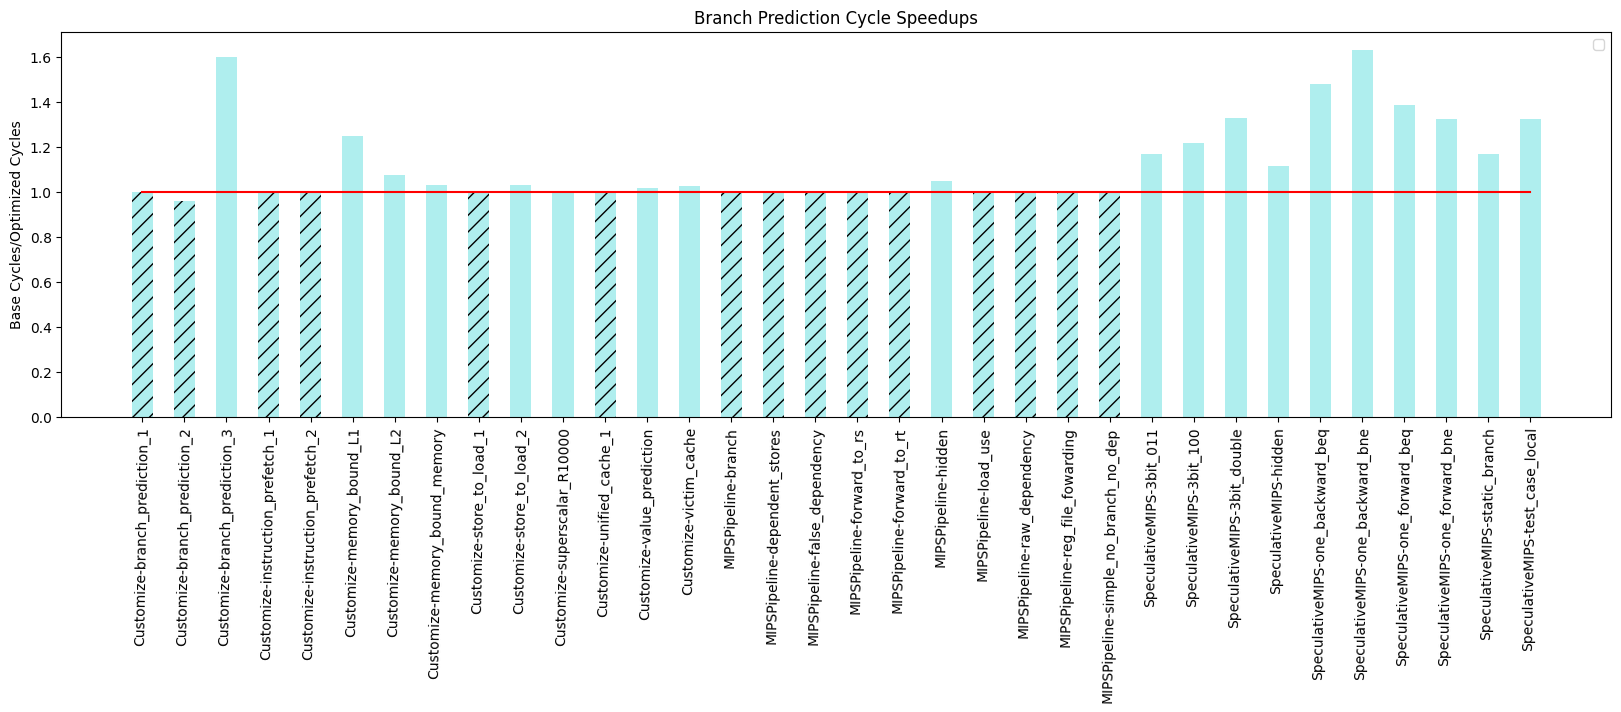

In [172]:
line_values = [1]* len(tests)

# Setting the positions and width for the bars
pos = np.arange(len(tests))

plt.figure(figsize=(20, 5))

# # === OOO BARS ===
# width = 0.2
# bp_bars = plt.bar(pos - width/2, bp_speedup, width, label='Branch Prediction', color="paleturquoise")
# ooo_bars = plt.bar(pos + width/2, ooo_speedup, width, label='OOO + Branch Prediction', color="sandybrown")

# for bar, value in zip(bp_bars, bp_speedup):
#     if value <= 1:
#         bar.set_hatch('//')  # Set to dashed


# for bar, value in zip(ooo_bars, ooo_speedup):
#     if value <= 1:
#         bar.set_hatch('//')  # Set to dashed



# plt.title('Optimization Cycle Speedups')

# # === OOO BARS ===


# ===BP BARS===
width = 0.5
bars = bar = plt.bar(tests, bp_speedup, width, color="paleturquoise")
for bar, value in zip(bars, bp_speedup):
    if value <= 1:
        bar.set_hatch('//')  # Set to dashed
plt.title('Branch Prediction Cycle Speedups')

# ===BP BARS===



plt.plot(tests, line_values, color='red')

# Adding labels and title
plt.xticks(pos, tests, rotation=89)
plt.ylabel('Base Cycles/Optimized Cycles')

# Adding legend
plt.legend()

# Display the graph
plt.show()

In [198]:
def dump_time_logs(prefix):
  command = ""
  for dirpath, dirnames, filenames in os.walk("compiled-tests"):
    for file in filenames:
      test_path = os.path.join(dirpath, file).replace("\\", "/")
      logname = file.rsplit("-test", maxsplit=1)[0]
      if logname == "Customize-memory_random":
        continue
      command += f'time ./processor --bmk={test_path} -O2 > time-logs/{prefix}-{logname}-log && '
    print(command.rsplit("&&", maxsplit=1)[0])
dump_time_logs("ooo")

time ./processor --bmk=compiled-tests/Customize-branch_prediction_1-test -O2 > time-logs/ooo-Customize-branch_prediction_1-log && time ./processor --bmk=compiled-tests/Customize-branch_prediction_2-test -O2 > time-logs/ooo-Customize-branch_prediction_2-log && time ./processor --bmk=compiled-tests/Customize-branch_prediction_3-test -O2 > time-logs/ooo-Customize-branch_prediction_3-log && time ./processor --bmk=compiled-tests/Customize-instruction_prefetch_1-test -O2 > time-logs/ooo-Customize-instruction_prefetch_1-log && time ./processor --bmk=compiled-tests/Customize-instruction_prefetch_2-test -O2 > time-logs/ooo-Customize-instruction_prefetch_2-log && time ./processor --bmk=compiled-tests/Customize-memory_bound_L1-test -O2 > time-logs/ooo-Customize-memory_bound_L1-log && time ./processor --bmk=compiled-tests/Customize-memory_bound_L2-test -O2 > time-logs/ooo-Customize-memory_bound_L2-log && time ./processor --bmk=compiled-tests/Customize-memory_bound_memory-test -O2 > time-logs/ooo-C